<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fa9200;">Use Indicators data to build LSTM Equivalent
    
<span style="font-family: Arial; font-weight:bold;font-size:2.1em;color:#fff;">-----------------------------------

### Import Packages

In [1]:
import torch
import itertools
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from datetime import date, datetime, timedelta
import os
import re
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import statsmodels.formula.api as sm
import statsmodels.stats.power as smp
from scipy import stats
import yfinance as yf
import plotly.express as px
import plotly.graph_objects as go
import plotly
from scipy.signal import argrelextrema
from collections import defaultdict
import sqlite3
import warnings
warnings.filterwarnings("ignore")
import Indicators
import Measurement
import Charts

### Add Variables

In [2]:
M = 80
K = 500
window = 7
smoothing = 7
events = {'ihs_event':'bull','hs_event':'bear','fw_event':'bull','rw_event':'bear'}
bound = 0.03
SMAs = [30,60,90]
event = 'rw_event'

### Run Functions to Get Data and Indicators

In [3]:
df3, final4 = Measurement.main(events, SMAs, smoothing, window, M, K, bound)

BRK.B: No data found, symbol may be delisted
'DataFrame' object has no attribute 'Datetime'
BF.B: Period '500d' is invalid, must be one of ['1mo', '3mo', '6mo', 'ytd', '1y', '2y', '5y', '10y', 'max']
'DataFrame' object has no attribute 'Datetime'


### Keep only columns Needed

In [4]:
cols = ['ticker','date','open','high','low','close','SMA30','SMA60','SMA90','rw_event','rw_event_none','rw_event_group',
        'rw_event_start_time','rw_event_end_time']
test = df3[cols].copy()
test.head(2)

,ticker,date,open,high,low,close,SMA30,SMA60,SMA90,rw_event,rw_event_none,rw_event_group,rw_event_start_time,rw_event_end_time
0,ZTS,2022-09-08 09:30:00,158.809998,158.809998,154.485001,157.335007,NaN,NaN,NaN,0,1,1,2022-09-08 09:30:00,2024-09-04 13:30:00
1,ZTS,2022-09-08 10:30:00,157.335007,160.229996,157.289993,160.009995,NaN,NaN,NaN,0,1,1,2022-09-08 09:30:00,2024-09-04 13:30:00


### <ins>Tangent:</ins> Looking for Large Changes in Stock Price

In [5]:
smaList = [x for x in test.columns if 'SMA' in x]
for s in smaList:
    test[s + '_chng'] = (test['close'] - test[s])/test['close']
test.head(2)

,ticker,date,open,high,low,close,SMA30,SMA60,SMA90,rw_event,rw_event_none,rw_event_group,rw_event_start_time,rw_event_end_time,SMA30_chng,SMA60_chng,SMA90_chng
0,ZTS,2022-09-08 09:30:00,158.809998,158.809998,154.485001,157.335007,NaN,NaN,NaN,0,1,1,2022-09-08 09:30:00,2024-09-04 13:30:00,NaN,NaN,NaN
1,ZTS,2022-09-08 10:30:00,157.335007,160.229996,157.289993,160.009995,NaN,NaN,NaN,0,1,1,2022-09-08 09:30:00,2024-09-04 13:30:00,NaN,NaN,NaN


### Run PCA on specified event

In [6]:
test.dropna(inplace=True)
chngList = [x for x in test.columns if 'chng' in x]
X = test[chngList].values
X = StandardScaler().fit_transform(X)
pca_fit = PCA(n_components=2)
pcomp = pca_fit.fit_transform(X)
pcomp

array([[ 1.80906228,  0.58536594],
       [ 1.88750743,  0.56488467],
       [ 1.69415741,  0.61006398],
       ...,
       [-0.31495109, -0.27796553],
       [-0.39589777, -0.2507919 ],
       [-0.30065718, -0.26705339]])

### ADD PCA to DF

In [7]:
test['pca1'] = pcomp[:,0]
test['pca2'] = pcomp[:,0]
test.head(2)

,ticker,date,open,high,low,close,SMA30,SMA60,SMA90,rw_event,rw_event_none,rw_event_group,rw_event_start_time,rw_event_end_time,SMA30_chng,SMA60_chng,SMA90_chng,pca1,pca2
106,ZTS,2022-09-26 14:30:00,148.580002,149.509995,148.289993,149.009995,150.766909,154.131517,156.931010,0,1,1,2022-09-08 09:30:00,2024-09-04 13:30:00,-0.011791,-0.034370,-0.053158,1.809062,1.809062
107,ZTS,2022-09-26 15:30:00,149.070007,149.710007,148.610001,148.679993,150.649909,153.924266,156.834843,0,1,1,2022-09-08 09:30:00,2024-09-04 13:30:00,-0.013249,-0.035272,-0.054848,1.887507,1.887507


### ScatterPlot PCA Results

In [8]:
test2 = test.sample(frac=.1).copy()
fig = go.Figure()
fig.add_trace(go.Scatter(x=test2[test2[event]==0].pca1, 
                    y=test2[test2[event]==0].pca2,
                    mode='markers',
                    name='markers',
                    ))
fig.add_trace(go.Scatter(x=test2[test2[event]==1].pca1, 
                    y=test2[test2[event]==1].pca2,
                    mode='markers',
                    name='markers',
                    ))
plotly.offline.plot(fig, filename='C:/Users/rschaub/Downloads/test.html')

'C:/Users/rschaub/Downloads/test.html'

### Histogram of PCA Results

In [9]:
fig = px.histogram(test2, x="pca1", color=event, nbins=200)
plotly.offline.plot(fig, filename='C:/Users/rschaub/Downloads/test.html')

'C:/Users/rschaub/Downloads/test.html'

### Note: The Scatter plot appeared to show that the successful indicators have a tighter distribution, but upon further investigation the historgram appears to show that the distributions are in fact similar but there are less outliers in the successful data set, perhaps due to the smaller number of observations. We can confirm this by picking a significant sample size and using A/B testing

### Create Function for Cohen's d

In [10]:
def cohens_d(group1, group2):
    # Calculating means of the two groups
    mean1, mean2 = np.mean(group1), np.mean(group2)
     
    # Calculating pooled standard deviation
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1 - 1) * std1 ** 2 + (n2 - 1) * std2 ** 2) / (n1 + n2 - 2))
     
    # Calculating Cohen's d
    d = (mean1 - mean2) / pooled_std
     
    return d

### Determine Sample Size

In [11]:
effect_size = 0.01  # The desired effect size (e.g., Cohen's d)
alpha = 0.05  # The significance level (e.g., 0.05)
power = 0.95  # The desired statistical power (e.g., 0.8)

test_a = test2[test2[event]==0].copy()
test_b = test2[test2[event]==1].copy()
print(len(test_a),len(test_b))
effect_size = cohens_d(test_a.pca1, test_b.pca1)
print("Cohen's d:", effect_size)

# For a paired t-test
power_analysis = smp.TTestPower()
sample_size = power_analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power)

# Round up to the nearest integer
sample_size = round(sample_size)

print("Required Sample Size:", sample_size)

163848 4240
Cohen's d: 0.5377817075212991
Required Sample Size: 47


### Run A/B Test

In [12]:
mu_a = test_a.pca1.mean()
mu_b = test_b.pca1.mean()
#t_stat, p_value = stats.ttest_1samp(test_b.pca1, mu_a)
t_stat, p_value = stats.ttest_ind(test_a.pca1, test_b.pca1)
print("T statistic:", t_stat)
print("P-value:", p_value)

T statistic: 34.57332681104913
P-value: 5.291633963268049e-261


### Create BoxPlot of DataSets

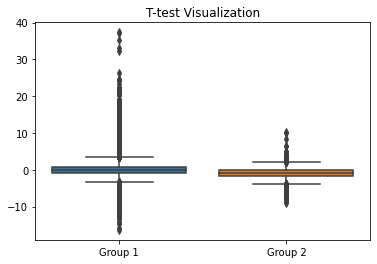

In [13]:
sns.boxplot(data=[test_a.pca1, test_b.pca1])
plt.xticks([0, 1], ['Group 1', 'Group 2'])
plt.title('T-test Visualization')
plt.show()

In [14]:
dbscan = DBSCAN(eps=0.1, min_samples=5)
# Fit the model
dbscan.fit(test_b[['pca1','pca2']])
# Get the cluster labels
labels = dbscan.labels_

In [15]:
test_b['db_scan'] = labels
test_b.groupby(['db_scan']).pca1.mean()

db_scan
-1   -0.944952
 0   -0.862206
 1   -5.156207
 2    3.400141
 3   -5.006199
 4   -4.864881
Name: pca1, dtype: float64